#  — Part A: SpaGCN Spatial Domain Detection (151676)

DLPFC 10x Visium slice **151676**: identify cortical layers with SpaGCN and evaluate against manual annotations.

## Task 1 — SpaGCN method and multimodal fusion

**Computational basis:** SpaGCN uses a **graph convolutional network (GCN)** combined with **deep embedded clustering (DEC)**. Gene expression is PCA-reduced; a GCN propagates information along a spot graph so each spot’s representation reflects its neighbours.

**Modalities integrated:**
1. **Gene expression** (spot-level count matrix)
2. **Spatial coordinates** (array / pixel positions on the tissue)
3. **Histology** (RGB intensities from H&E image around each spot)

**Fusion type:** **Early fusion at graph construction** — not late fusion of separate models. Pairwise spot distances combine spatial \((x,y)\) and a histology-derived feature \(z\) (weighted by parameter **s** = `alpha`). The adjacency matrix is built from these distances, then exponentiated with bandwidth **l**. Expression enters only through GCN message passing on that graph.

**Parameter s:** scales histology variance relative to spatial coordinates. `s=0` → spatial-only graph; larger `s` → stronger histology influence on neighbourhood structure.

In [1]:
import os
import pandas as pd
import numpy as np
import scanpy as sc
import SpaGCN as spg
from scipy.sparse import issparse
import random
import torch
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
import cv2
from sklearn.cluster import KMeans
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    confusion_matrix,
    classification_report,
)
from scipy.optimize import linear_sum_assignment

warnings.filterwarnings("ignore")
sc.settings.verbosity = 2

# Local data path (change if running on Nuvolos)
DATA_DIR = os.path.join(os.getcwd(), "151676")
if not os.path.isdir(DATA_DIR):
    DATA_DIR = "/root/autodl-tmp/ML/151676"

N_CLUSTERS = 7  # number of ground-truth cortical layers + WM
S_VALUES = [1, 0, 10]  # primary run s=1, then comparison

/root/miniconda3/lib/python3.12/site-packages/anndata/__init__.py:70: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  return module_get_attr_redirect(attr_name, deprecated_mapping=_DEPRECATED)
/root/miniconda3/lib/python3.12/site-packages/anndata/__init__.py:70: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  return module_get_attr_redirect(attr_name, deprecated_mapping=_DEPRECATED)
/root/miniconda3/lib/python3.12/site-packages/anndata/__init__.py:70: FutureWarning: Importing read_mtx from `anndata` is deprecated. Import anndata.io.read_mtx instead.
  return module_get_attr_redirect(attr_name, deprecated_mapping=_DEPRECATED)
/root/miniconda3/lib/python3.12/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading laye

## Task 2 — Load Visium data and histology image

In [2]:
# Gene expression + spatial (Visium)
adata_spg = sc.read_visium(
    path=DATA_DIR,
    count_file="filtered_feature_bc_matrix.h5",
    load_images=True,
)
adata_spg.var_names_make_unique()
adata_spg.var["SYMBOL"] = adata_spg.var_names

# Ground-truth cortical layer labels
histo_2 = pd.read_csv(os.path.join(DATA_DIR, "151676_truth.txt"), sep="\t").dropna()
histo_2.index = histo_2["Barcode"]
adata_spg = adata_spg[adata_spg.obs_names.isin(histo_2["Barcode"]), :].copy()

# Spot coordinates (array + full-res pixels)
spatial = pd.read_csv(
    os.path.join(DATA_DIR, "spatial", "tissue_positions_list.csv"),
    sep=",",
    header=None,
    na_filter=False,
    index_col=0,
)
for i in range(1, 6):
    adata_spg.obs[f"x{i}"] = spatial.loc[adata_spg.obs_names, i].values
adata_spg = adata_spg[adata_spg.obs["x1"] == 1].copy()
adata_spg.obs["x_array"] = adata_spg.obs["x2"].astype(float)
adata_spg.obs["y_array"] = adata_spg.obs["x3"].astype(float)
adata_spg.obs["x_pixel"] = adata_spg.obs["x4"].astype(int)
adata_spg.obs["y_pixel"] = adata_spg.obs["x5"].astype(int)

# Full-resolution H&E image
img = cv2.imread(os.path.join(DATA_DIR, "spatial", "151676_full_image.tif"))
assert img is not None, "Histology image not found"

adata_spg.obs["ground_truth"] = histo_2.loc[adata_spg.obs_names, "Annotations"].values
print(f"Spots: {adata_spg.n_obs}, Genes: {adata_spg.n_vars}")
print("Ground-truth layers:\n", adata_spg.obs["ground_truth"].value_counts())

reading /root/autodl-tmp/ML/151676/filtered_feature_bc_matrix.h5
 (0:00:00)


[ WARN:0@0.947] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 40961 (0xa001) encountered
[ WARN:0@0.947] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 65325 (0xff2d) encountered
[ WARN:0@0.947] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 65326 (0xff2e) encountered
[ WARN:0@0.947] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 65327 (0xff2f) encountered
[ WARN:0@0.947] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 65329 (0xff31) encountered
[ WARN:0@0.947] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 65330 (0xff32) encountered
[ WARN:0@0.947] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 65331 (0xff33) encountered
[ WARN:0@0.947] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 65332 (0xff34) encountered
[ WARN:0

Spots: 3431, Genes: 33538
Ground-truth layers:
 ground_truth
Layer_3    836
Layer_5    649
Layer_6    616
WM         533
Layer_1    289
Layer_2    254
Layer_4    254
Name: count, dtype: int64


## Task 3 — Preprocess expression data

In [3]:
adata_pp = adata_spg.copy()
spg.prefilter_genes(adata_pp, min_cells=3)
spg.prefilter_specialgenes(adata_pp)  # remove MT / ERCC
sc.pp.normalize_per_cell(adata_pp)
sc.pp.log1p(adata_pp)
# SpaGCN 1.2.x uses .A on sparse matrices (removed in recent scipy)
if issparse(adata_pp.X):
    adata_pp.X = adata_pp.X.toarray()
print(f"After filtering: {adata_pp.n_obs} spots, {adata_pp.n_vars} genes")

filtered out 14877 genes that are detected in less than 3 cells


normalizing by total count per cell
    finished (0:00:00): normalized adata.X and added
    'n_counts', counts per cell before normalization (adata.obs)
After filtering: 3431 spots, 18640 genes


## Tasks 4–8 — SpaGCN pipeline, K-means, visualisation, evaluation

Helper functions below run SpaGCN for a given **s**, apply **K-means** on the GCN latent embedding (dimension = 50), and compute metrics vs ground truth.

In [4]:
def find_l_param(adj, s):
    """Search bandwidth l so ~50% expression comes from neighbours (p=0.5)."""
    p = 0.5
    if s == 0:
        l = spg.search_l(p, adj, start=0.01, end=1000, tol=0.01, max_run=100)
        if l is None:
            l = spg.find_l(p=p, adj=adj, start=0.5, end=200, sep=0.5, tol=0.05)
    else:
        l = spg.find_l(p=p, adj=adj, start=100, end=500, sep=1, tol=0.01)
        if l is None:
            l = spg.search_l(p, adj, start=0.01, end=1000, tol=0.01, max_run=100)
    return float(l)


def run_spagcn_kmeans(adata, img, s, n_clusters=N_CLUSTERS, seed=100):
    """SpaGCN training + K-means on GCN embedding."""
    x_array = adata.obs["x_array"].tolist()
    y_array = adata.obs["y_array"].tolist()
    x_pixel = adata.obs["x_pixel"].tolist()
    y_pixel = adata.obs["y_pixel"].tolist()

    if s == 0:
        adj = spg.calculate_adj_matrix(x=x_array, y=y_array, histology=False)
    else:
        adj = spg.calculate_adj_matrix(
            x=x_pixel,
            y=y_pixel,
            x_pixel=x_pixel,
            y_pixel=y_pixel,
            image=img,
            beta=49,
            alpha=s,
            histology=True,
        )

    l = find_l_param(adj, s)
    res = spg.search_res(
        adata,
        adj,
        l,
        n_clusters,
        start=0.7,
        step=0.1,
        tol=5e-3,
        lr=0.05,
        max_epochs=20,
        r_seed=seed,
        t_seed=seed,
        n_seed=seed,
    )

    clf = spg.SpaGCN()
    clf.set_l(l)
    random.seed(seed)
    torch.manual_seed(seed)
    np.random.seed(seed)
    clf.train(
        adata,
        adj,
        init_spa=True,
        init="louvain",
        res=res,
        tol=5e-3,
        lr=0.05,
        max_epochs=200,
    )

    with torch.no_grad():
        z, _ = clf.model.predict(
            torch.FloatTensor(clf.embed), torch.FloatTensor(clf.adj_exp)
        )
    z_np = z.detach().cpu().numpy()
    km_labels = KMeans(n_clusters=n_clusters, n_init=20, random_state=seed).fit_predict(z_np)

    return {
        "labels": km_labels,
        "l": l,
        "res": res,
        "adj": adj,
        "clf": clf,
    }


def hungarian_map_clusters_to_layers(y_true, y_pred):
    """Map K-means cluster IDs (0..K-1) to ground-truth layer names via Hungarian algorithm.

    Confusion matrix: rows = predicted clusters, columns = ground-truth layers.
    Maximises total overlap (minimises negative overlap cost).
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred, dtype=int)

    layer_names = sorted(np.unique(y_true))
    cluster_ids = sorted(int(x) for x in np.unique(y_pred))

    # rows = clusters, columns = layers
    confusion = pd.crosstab(
        pd.Series(y_pred, name="predicted_cluster"),
        pd.Series(y_true, name="ground_truth_layer"),
    )
    confusion = confusion.reindex(index=cluster_ids, columns=layer_names, fill_value=0)

    row_ind, col_ind = linear_sum_assignment(-confusion.values.astype(np.int64))

    cluster_to_layer = {}
    for k in range(len(row_ind)):
        cluster_id = cluster_ids[row_ind[k]]
        layer_name = layer_names[col_ind[k]]
        cluster_to_layer[cluster_id] = layer_name

    y_pred_layer = np.array([cluster_to_layer[int(c)] for c in y_pred])
    return confusion, cluster_to_layer, y_pred_layer


def evaluate_clustering(adata, cluster_labels, label_col="ground_truth"):
    """ARI/NMI on raw cluster IDs; per-layer metrics on Hungarian-matched layer names."""
    cluster_labels = np.asarray(cluster_labels, dtype=int)
    y_true = np.asarray(adata.obs[label_col].values)

    ari = adjusted_rand_score(y_true, cluster_labels)
    nmi = normalized_mutual_info_score(y_true, cluster_labels)

    confusion, cluster_to_layer, y_pred_layer = hungarian_map_clusters_to_layers(
        y_true, cluster_labels
    )

    layer_names = sorted(np.unique(y_true))
    report = classification_report(
        y_true, y_pred_layer, labels=layer_names, zero_division=0
    )
    report_dict = classification_report(
        y_true, y_pred_layer, labels=layer_names, zero_division=0, output_dict=True
    )
    per_layer_f1 = {
        layer: report_dict[layer]["f1-score"]
        for layer in layer_names
        if layer in report_dict
    }

    return {
        "ARI": ari,
        "NMI": nmi,
        "confusion": confusion,
        "cluster_to_layer": cluster_to_layer,
        "y_pred_layer": y_pred_layer,
        "report": report,
        "per_layer_f1": per_layer_f1,
    }


def plot_spatial_layers(adata, layer_labels, title, ax=None, palette="tab10"):
    """Spatial plot using Hungarian-matched predicted layer names."""
    plot_df = adata.obs.copy()
    plot_df["predicted_layer"] = np.asarray(layer_labels)
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))
    sns.scatterplot(
        data=plot_df,
        x="x_array",
        y="y_array",
        hue="predicted_layer",
        hue_order=sorted(plot_df["predicted_layer"].unique()),
        palette=palette,
        s=12,
        linewidth=0,
        ax=ax,
        legend="brief",
    )
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.invert_yaxis()
    return ax

### Task 4–7 — Primary run: **s = 1**

In [5]:
results = {}
metrics_table = []

for s in S_VALUES:
    print(f"\n{'='*60}\nRunning SpaGCN with s = {s}\n{'='*60}")
    out = run_spagcn_kmeans(adata_pp, img, s=s)
    eval_res = evaluate_clustering(adata_pp, out["labels"])
    results[s] = {**out, **eval_res}
    metrics_table.append({"s": s, "l": out["l"], "res": out["res"], "ARI": eval_res["ARI"], "NMI": eval_res["NMI"]})
    print(f"l={out['l']:.4f}, Louvain res={out['res']:.3f}")
    print(f"ARI={eval_res['ARI']:.4f}, NMI={eval_res['NMI']:.4f}")

metrics_df = pd.DataFrame(metrics_table).set_index("s")
metrics_df


Running SpaGCN with s = 1
Calculateing adj matrix using histology image...
Var of c0,c1,c2 =  29.477509465304824 174.8015556779522 60.95093839727311
Var of x,y,z =  5080995.703721643 4365111.426668278 5080995.703721643


L= 100 P= 0.28798
L= 101 P= 0.29841
L= 102 P= 0.30904
L= 103 P= 0.31989
L= 104 P= 0.33094
L= 105 P= 0.34221
L= 106 P= 0.35369
L= 107 P= 0.36538
L= 108 P= 0.37728
L= 109 P= 0.38941
L= 110 P= 0.40175
L= 111 P= 0.41431
L= 112 P= 0.42709
L= 113 P= 0.44009
L= 114 P= 0.45332
L= 115 P= 0.46677
L= 116 P= 0.48045
L= 117 P= 0.49435
Start at res =  0.7 step =  0.1
Initializing cluster centers with louvain, resolution =  0.7
computing neighbors
    using data matrix X directly
    finished (0:00:14)
running Louvain clustering
    using the "louvain" package of Traag (2017)
    finished (0:00:00)
Epoch  0
Epoch  10
Res =  0.7 Num of clusters =  6
Initializing cluster centers with louvain, resolution =  0.7999999999999999
computing neighbors
    using data matrix X directly
    finished (0:00:00)
running Louvain clustering
    using the "louvain" package of Traag (2017)
    finished (0:00:00)
Epoch  0
Epoch  10
Res =  0.7999999999999999 Num of clusters =  8
Step changed to 0.05
Initializing cluster 

,l,res,ARI,NMI
s,,,,
1,117.00000,0.75,0.351534,0.473866
0,0.68138,0.80,0.413913,0.542930
10,249.00000,0.65,0.358540,0.468963


### Task 6 — Spatial visualisation (Hungarian-matched predicted layers vs ground truth)

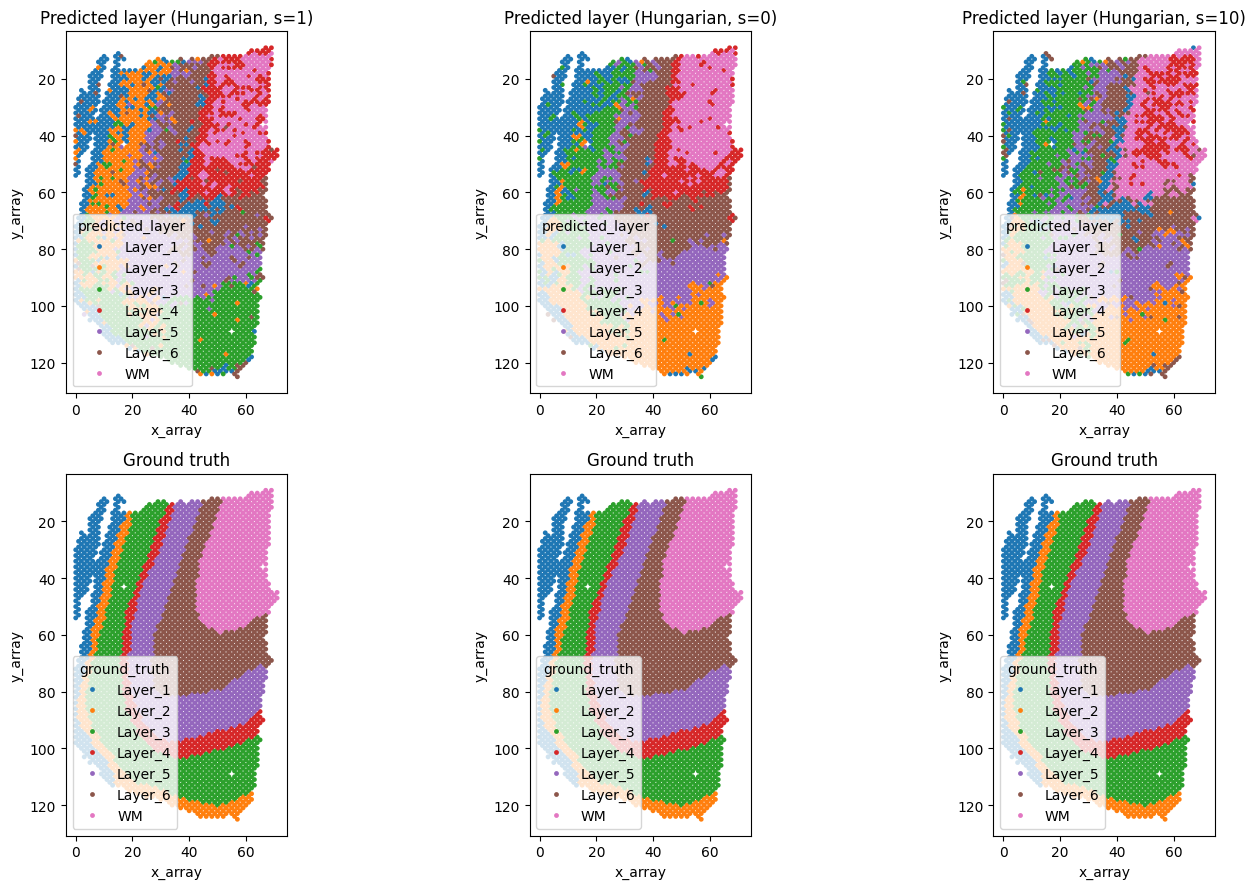

In [6]:
fig, axes = plt.subplots(2, len(S_VALUES), figsize=(5 * len(S_VALUES), 9))
if len(S_VALUES) == 1:
    axes = axes.reshape(2, 1)

layer_palette = {
    layer: c
    for layer, c in zip(
        sorted(adata_pp.obs["ground_truth"].unique()),
        sns.color_palette("tab10", n_colors=7),
    )
}

for j, s in enumerate(S_VALUES):
    plot_spatial_layers(
        adata_pp,
        results[s]["y_pred_layer"],
        f"Predicted layer (Hungarian, s={s})",
        ax=axes[0, j],
        palette=layer_palette,
    )
    plot_df = adata_pp.obs.copy()
    sns.scatterplot(
        data=plot_df,
        x="x_array",
        y="y_array",
        hue="ground_truth",
        hue_order=sorted(plot_df["ground_truth"].unique()),
        palette=layer_palette,
        s=12,
        linewidth=0,
        ax=axes[1, j],
        legend="brief",
    )
    axes[1, j].set_title("Ground truth")
    axes[1, j].set_aspect("equal")
    axes[1, j].invert_yaxis()

plt.tight_layout()
plt.savefig("partA_spatial_matched_layers.png", dpi=200, bbox_inches="tight")
plt.show()

### Task 7 — Overall clustering performance

### Task 8 — Per-layer precision / recall / F1 (Hungarian-matched, all s)

In [7]:
# Cluster -> layer mapping (Hungarian)
for s in S_VALUES:
    print(f"\nCluster -> layer mapping (s={s}):")
    for cid, layer in sorted(results[s]["cluster_to_layer"].items()):
        print(f"  cluster {cid} -> {layer}")

# Confusion matrix: rows = predicted clusters, columns = ground-truth layers
s_main = 1
print(f"\nConfusion matrix (rows=clusters, cols=layers), s={s_main}:")
display(results[s_main]["confusion"])

print(f"\nPer-layer classification report (s={s_main}):")
print(results[s_main]["report"])

# Per-layer F1 for s=0, s=1, s=10
f1_rows = []
for s in S_VALUES:
    for layer, f1 in results[s]["per_layer_f1"].items():
        f1_rows.append({"s": s, "layer": layer, "f1": f1})
per_layer_f1_df = pd.DataFrame(f1_rows).pivot(index="layer", columns="s", values="f1")
per_layer_f1_df.columns = [f"s={c}" for c in per_layer_f1_df.columns]
per_layer_f1_df = per_layer_f1_df.reindex(sorted(adata_pp.obs["ground_truth"].unique()))
print("\nPer-layer F1 (Hungarian-matched predictions):")
per_layer_f1_df


Cluster -> layer mapping (s=1):
  cluster 0 -> Layer_5
  cluster 1 -> Layer_4
  cluster 2 -> Layer_3
  cluster 3 -> WM
  cluster 4 -> Layer_1
  cluster 5 -> Layer_2
  cluster 6 -> Layer_6

Cluster -> layer mapping (s=0):
  cluster 0 -> WM
  cluster 1 -> Layer_2
  cluster 2 -> Layer_1
  cluster 3 -> Layer_4
  cluster 4 -> Layer_5
  cluster 5 -> Layer_6
  cluster 6 -> Layer_3

Cluster -> layer mapping (s=10):
  cluster 0 -> Layer_2
  cluster 1 -> Layer_6
  cluster 2 -> WM
  cluster 3 -> Layer_3
  cluster 4 -> Layer_4
  cluster 5 -> Layer_1
  cluster 6 -> Layer_5

Confusion matrix (rows=clusters, cols=layers), s=1:


ground_truth_layer,Layer_1,Layer_2,Layer_3,Layer_4,Layer_5,Layer_6,WM
predicted_cluster,,,,,,,
0,1,0,41,79,409,62,0
1,0,0,0,0,0,105,257
2,13,139,415,92,15,3,0
3,0,0,0,0,0,8,268
4,238,44,49,15,5,84,0
5,29,56,321,53,31,2,0
6,8,15,10,15,189,352,8



Per-layer classification report (s=1):
              precision    recall  f1-score   support

     Layer_1       0.55      0.82      0.66       289
     Layer_2       0.11      0.22      0.15       254
     Layer_3       0.61      0.50      0.55       836
     Layer_4       0.00      0.00      0.00       254
     Layer_5       0.69      0.63      0.66       649
     Layer_6       0.59      0.57      0.58       616
          WM       0.97      0.50      0.66       533

    accuracy                           0.51      3431
   macro avg       0.50      0.46      0.47      3431
weighted avg       0.59      0.51      0.53      3431


Per-layer F1 (Hungarian-matched predictions):


,s=0,s=1,s=10
layer,,,
Layer_1,0.698140,0.657459,0.607092
Layer_2,0.362600,0.150134,0.317274
Layer_3,0.475056,0.548579,0.511563
Layer_4,0.000000,0.000000,0.000000
Layer_5,0.688372,0.659146,0.711178
Layer_6,0.728631,0.580379,0.598065
WM,0.820961,0.662546,0.657417


## Tasks 9–10 — Effect of histology contribution parameter

Task 9 was completed by repeating the SpaGCN-KMeans pipeline under s=0, s=1 and s=10.

The overall metrics show that s=0 achieved the best ARI and NMI in this sample. Per-layer F1-scores further indicate that WM, Layer_6 and Layer_1 were better recovered under s=0, whereas Layer_5 was best recovered under s=10 and Layer_3 under s=1. Layer_4 was not recovered under any setting. These results suggest that increasing the histology contribution did not uniformly improve clustering performance. In this DLPFC section, stronger histology weighting may have introduced stain-related variation or over-smoothed neighbouring domains.